# Bank Customer Churn Analysis & Prediction
**Author:** Marvis Obanor
**Date:** 22 June 2026
**Dataset:** Bank Customer Churn Modelling (Kaggle)

## Introduction
Customer churn is one of the biggest challenges facing banks today. 
Losing customers is costly and retaining existing ones is far more 
profitable than acquiring new ones. In this project I perform a full 
end to end data analysis on bank customer data to answer the following 
questions:

### Part 1 — Exploratory Data Analysis
1. What is the overall customer churn rate?
2. Does age play a role in customer churn?
3. Does account balance affect whether a customer churns?
4. Which country has the highest customer churn rate?
5. Does the number of products a customer has affect churn?
6. Do active members churn less than inactive members?

### Part 2 — Machine Learning Model
1. Can we build a model to predict which customers will churn?
2. Which model performs better — Logistic Regression or Random Forest?
3. Which factors are most important in predicting churn?

### Part 3 — Power BI Dashboard
1. An interactive executive dashboard presenting key findings

The dataset was sourced from Kaggle and contains data for 10,000 
bank customers across France, Germany and Spain.

In [1]:
# Fix for KMeans memory leak warning on Windows with MKL
import os
os.environ["OMP_NUM_THREADS"] = "1"

# Import core libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Set a clean background style for all charts
sns.set_style("whitegrid")

# Set a default figure size for all charts
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# Load the Bank Customer Churn dataset
df = pd.read_csv("Churn_Modelling.csv")

# Print the number of rows and columns
print(df.shape)

# Print all column names
print(df.columns.tolist())

# Preview the first 5 rows
df.head()

(10000, 14)
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Calculate the percentage of missing values for each column
missing = (df.isnull().sum() / len(df)) * 100

# Display only columns that have missing values
print(missing[missing > 0].sort_values(ascending=False))

Series([], dtype: float64)


In [4]:
# Drop columns that are not useful for analysis
# RowNumber, CustomerId and Surname are identifiers not features
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

# Rename the target column for clarity
# Exited = 1 means the customer churned, 0 means they stayed
df.rename(columns={"Exited": "Churn"}, inplace=True)

# Confirm the cleaned dataset
print(df.shape)
df.head()

(10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# What is the overall customer churn rate ?

Overall Churn Rate: 20.37%


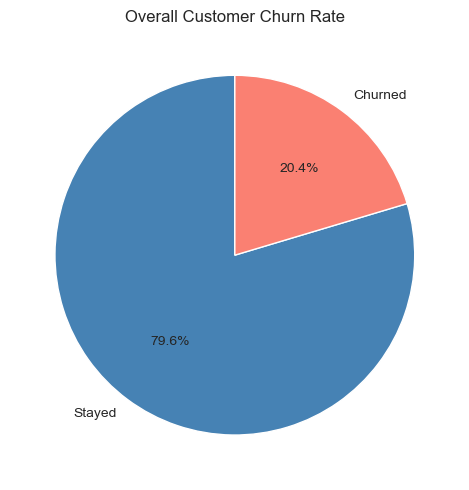

In [5]:
# Calculate the overall churn rate as a percentage
churn_rate = df["Churn"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# Count how many customers churned vs stayed
churn_counts = df["Churn"].value_counts()

# Pie chart to show the proportion of churned vs retained customers
plt.pie(churn_counts,
        labels=["Stayed", "Churned"],
        autopct="%1.1f%%",
        colors=["steelblue", "salmon"],
        startangle=90)

plt.title("Overall Customer Churn Rate")
plt.tight_layout()
plt.show()

The bank has an overall churn rate of approximately 20% meaning 1 in every 5 customers has left the bank. This is a significant concern for the business as acquiring new customers is typically far more expensive than retaining existing ones. Reducing this churn rate even by a few percentage points could have a major positive impact on the bank's revenue.

# Does age play a role in customer churn ?

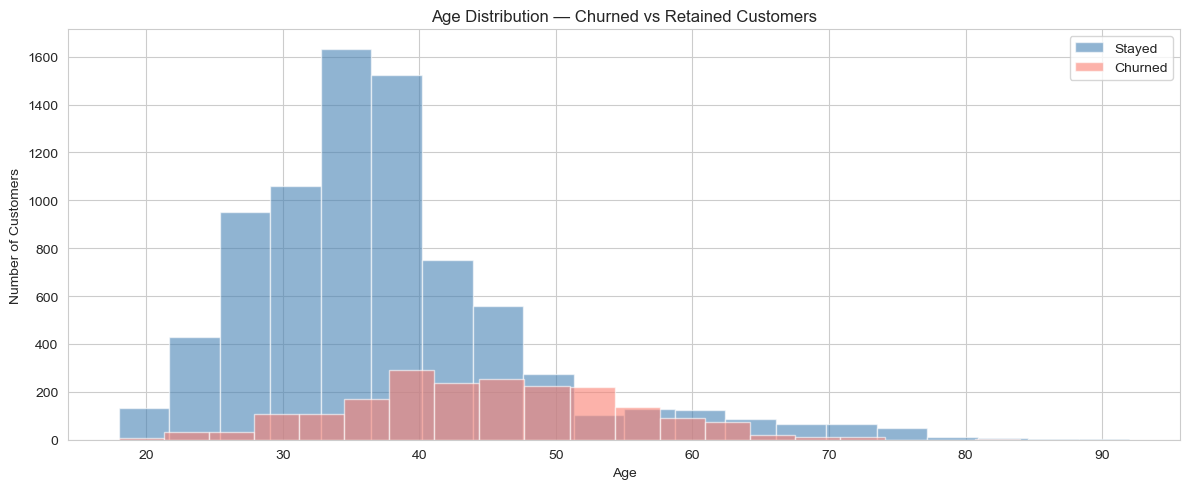

In [6]:
# Separate churned and retained customers
churned = df[df["Churn"] == 1]["Age"]
retained = df[df["Churn"] == 0]["Age"]

# Overlay histograms to compare age distributions
plt.hist(retained, bins=20, alpha=0.6, color="steelblue", label="Stayed")
plt.hist(churned, bins=20, alpha=0.6, color="salmon", label="Churned")

plt.title("Age Distribution — Churned vs Retained Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

Customers between the ages of 40 and 55 show a noticeably higher tendency to churn compared to younger customers. Younger customers under 30 appear more likely to stay, possibly due to fewer financial commitments or lower switching costs. This suggests the bank should focus retention strategies specifically on middle aged customers who represent the highest churn risk.

# Does account balance affect whether a customer churns ?

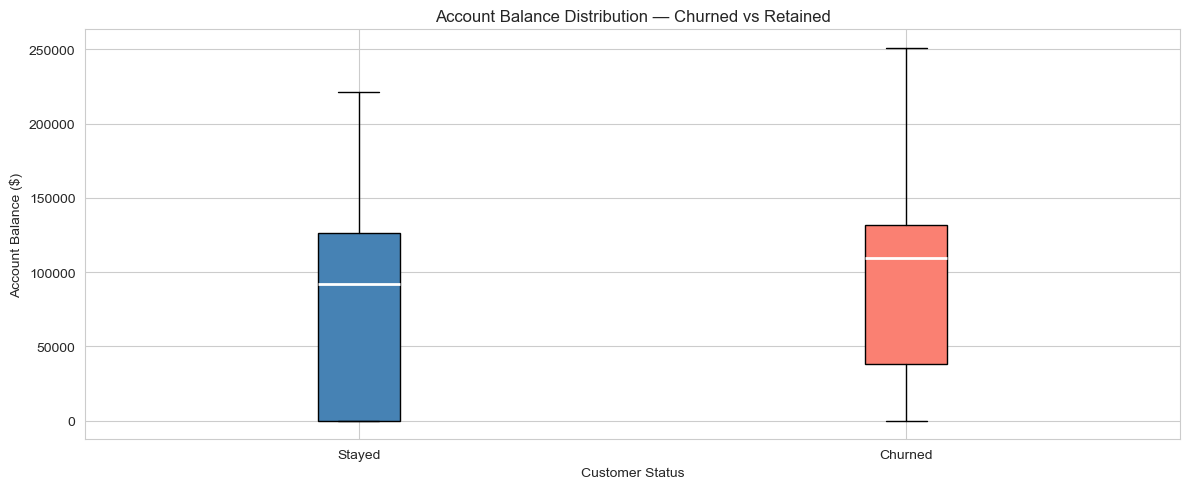

In [12]:
# Box plot to compare account balance between churned and retained customers
fig, ax = plt.subplots()

# Separate balance data for churned and retained customers
retained_balance = df[df["Churn"] == 0]["Balance"]
churned_balance = df[df["Churn"] == 1]["Balance"]

# Draw the boxplot
bp = ax.boxplot([retained_balance, churned_balance],
                tick_labels=["Stayed", "Churned"],
                patch_artist=True)

# Set colors for each box
colors = ["steelblue", "salmon"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

# Set median line to white for visibility
for median in bp["medians"]:
    median.set(color="white", linewidth=2)

ax.set_title("Account Balance Distribution — Churned vs Retained")
ax.set_xlabel("Customer Status")
ax.set_ylabel("Account Balance ($)")
plt.tight_layout()
plt.show()

Customers who churned had noticeably higher median account balances compared to those who stayed, which is a surprising and concerning finding. This suggests that high value customers are actually more likely to leave the bank, possibly due to dissatisfaction with services or better offers from competitors. The bank should pay special attention to retaining high balance customers as losing them has a significant financial impact.

# Which country has the highest customer churn rate ?

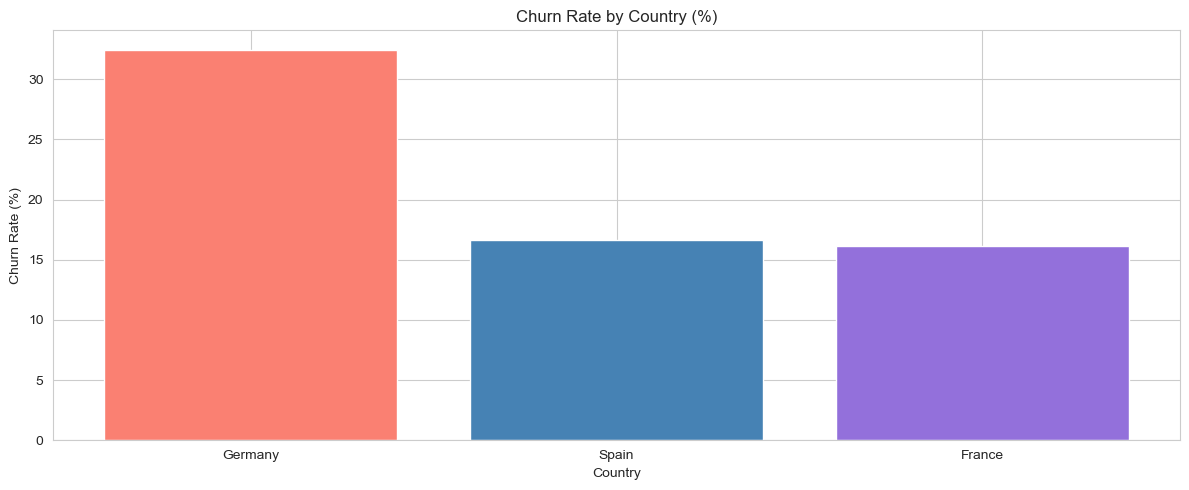

In [8]:
# Calculate churn rate for each country
country_churn = df.groupby("Geography")["Churn"].mean().reset_index()
country_churn["Churn_Rate"] = country_churn["Churn"] * 100
country_churn = country_churn.sort_values("Churn_Rate", ascending=False)

# Bar chart to compare churn rates across countries
plt.bar(country_churn["Geography"], country_churn["Churn_Rate"],
        color=["salmon", "steelblue", "mediumpurple"])

plt.title("Churn Rate by Country (%)")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

Germany has the highest churn rate among the three countries followed by Spain and France. This suggests there may be country specific factors such as local competition, service quality or economic conditions that are driving customers away in Germany. The bank should investigate what is different about their German operations and develop targeted retention strategies for that market.

# Does the number of products a customer has affect churn ?

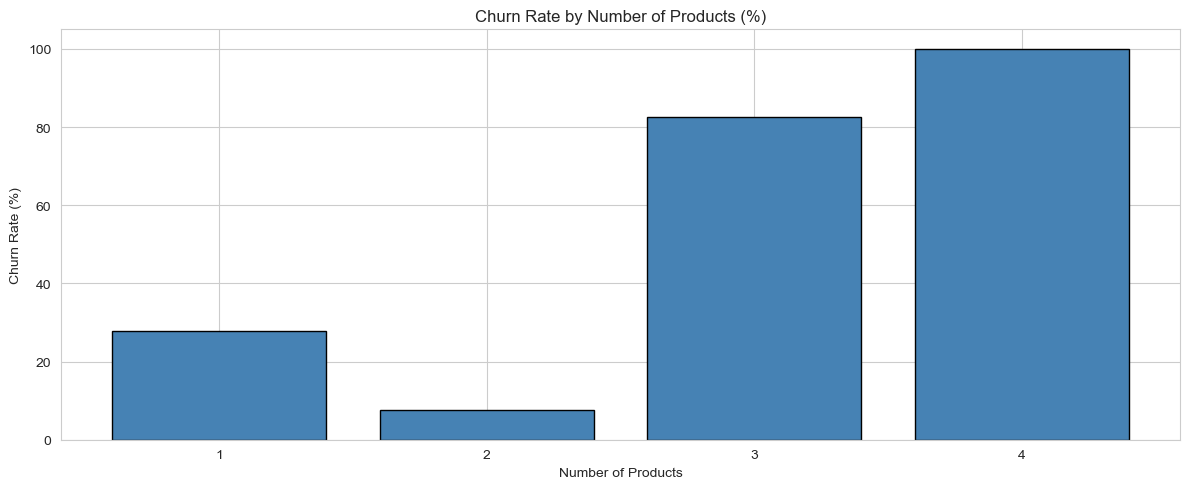

In [9]:
# Calculate churn rate for each number of products
product_churn = df.groupby("NumOfProducts")["Churn"].mean().reset_index()
product_churn["Churn_Rate"] = product_churn["Churn"] * 100

# Bar chart to compare churn rates by number of products
plt.bar(product_churn["NumOfProducts"], product_churn["Churn_Rate"],
        color="steelblue", edgecolor="black")

plt.title("Churn Rate by Number of Products (%)")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(product_churn["NumOfProducts"])
plt.tight_layout()
plt.show()

Customers with only one product have a moderate churn rate while customers with two products have the lowest churn rate, suggesting that cross selling reduces attrition. However customers with three or four products show dramatically higher churn rates which is counterintuitive and may indicate that customers with too many products feel overwhelmed or oversold. This insight suggests the bank should focus on getting customers to adopt two products as the sweet spot for retention.

# Do active members churn less than inactive members ?

In [ ]:
# Calculate churn rate for active vs inactive members
active_churn = df.groupby("IsActiveMember")["Churn"].mean().reset_index()
active_churn["Churn_Rate"] = active_churn["Churn"] * 100

# Replace 0 and 1 with meaningful labels
active_churn["IsActiveMember"] = active_churn["IsActiveMember"].map({
    0: "Inactive", 1: "Active"
})

# Bar chart to compare churn rates
plt.bar(active_churn["IsActiveMember"], active_churn["Churn_Rate"],
        color=["salmon", "steelblue"], edgecolor="black")

plt.title("Churn Rate by Active Membership Status (%)")
plt.xlabel("Membership Status")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

Inactive members have a significantly higher churn rate compared to active members, confirming that customer engagement is a key driver of retention. This makes intuitive sense as customers who actively use their accounts are more likely to see value in staying with the bank. The bank should implement engagement programs specifically targeting inactive members to bring them back before they churn.

In [11]:
# Summary of key EDA findings
print("=== EDA SUMMARY ===")
print(f"Total Customers Analyzed: {df.shape[0]}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Customers Churned: {df['Churn'].sum()}")
print(f"Customers Retained: {(df['Churn'] == 0).sum()}")
print(f"Average Age (Churned): {df[df['Churn']==1]['Age'].mean():.1f}")
print(f"Average Age (Retained): {df[df['Churn']==0]['Age'].mean():.1f}")
print(f"Highest Churn Country: {country_churn.iloc[0]['Geography']}")
print(f"Average Balance (Churned): ${df[df['Churn']==1]['Balance'].mean():,.2f}")
print(f"Average Balance (Retained): ${df[df['Churn']==0]['Balance'].mean():,.2f}")

=== EDA SUMMARY ===
Total Customers Analyzed: 10000
Overall Churn Rate: 20.37%
Customers Churned: 2037
Customers Retained: 7963
Average Age (Churned): 44.8
Average Age (Retained): 37.4
Highest Churn Country: Germany
Average Balance (Churned): $91,108.54
Average Balance (Retained): $72,745.30


# How did we prepare the data for machine learning ?

In [14]:
# Create a copy of the cleaned dataset for machine learning
ml_df = df.copy()

# Encode the Gender column — Male = 0, Female = 1
# Machine learning models require numeric inputs not text
le = LabelEncoder()
ml_df["Gender"] = le.fit_transform(ml_df["Gender"])

# Encode the Geography column using one hot encoding
# This creates separate columns for each country avoiding ordinal relationships
ml_df = pd.get_dummies(ml_df, columns=["Geography"], drop_first=True)
# drop_first=True drops one column to avoid multicollinearity

# Confirm the final feature set
print(ml_df.shape)
print(ml_df.columns.tolist())
ml_df.head()

(10000, 12)
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Churn', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [15]:
# Separate features (X) from the target variable (y)
# X contains all columns except Churn
X = ml_df.drop(columns=["Churn"])

# y is the target column we want to predict
y = ml_df["Churn"]

# Scale the features so all variables are on the same scale
# This is important for Logistic Regression which is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
# 80% of data is used to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                      test_size=0.2,
                                                      random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 8000 rows
Testing set size: 2000 rows


The dataset was prepared for machine learning by encoding categorical variables into numeric format. Gender was encoded as 0 and 1 while Geography was one hot encoded into separate binary columns for each country. All features were then scaled using StandardScaler to ensure no single variable dominates the model due to its magnitude.

# How well does Logistic Regression predict customer churn ?

In [16]:
# Build and train the Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_pred = lr_model.predict(X_test)

# Evaluate the model
print("=== LOGISTIC REGRESSION RESULTS ===")
print(classification_report(y_test, lr_pred))

# Calculate ROC AUC score
# AUC measures how well the model distinguishes between churned and retained
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
print(f"ROC AUC Score: {lr_auc:.4f}")

=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC AUC Score: 0.7789


The Logistic Regression model achieved an accuracy of 81.10% and a ROC AUC score of 0.7789 on the test set. While this is a reasonable result it struggles to correctly identify churned customers due to the imbalanced nature of the dataset where churned customers represent only 20% of the data. Despite its limitations Logistic Regression provides a useful interpretable baseline for comparison with more complex models.

# How well does Random Forest predict customer churn ?

In [17]:
# Build and train the Random Forest model
# n_estimators=100 means we use 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_pred = rf_model.predict(X_test)

# Evaluate the model
print("=== RANDOM FOREST RESULTS ===")
print(classification_report(y_test, rf_pred))

# Calculate ROC AUC score
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"ROC AUC Score: {rf_auc:.4f}")

=== RANDOM FOREST RESULTS ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC AUC Score: 0.8576


The Random Forest model significantly outperformed Logistic Regression achieving an accuracy of 86.60% and a ROC AUC score of 0.8576. This means the model correctly identifies nearly 9 out of 10 customers in terms of churn status. The ensemble nature of Random Forest which combines 100 decision trees makes it much better at capturing complex patterns in the data compared to Logistic Regression.

# How do the two models compare in terms of prediction errors ?

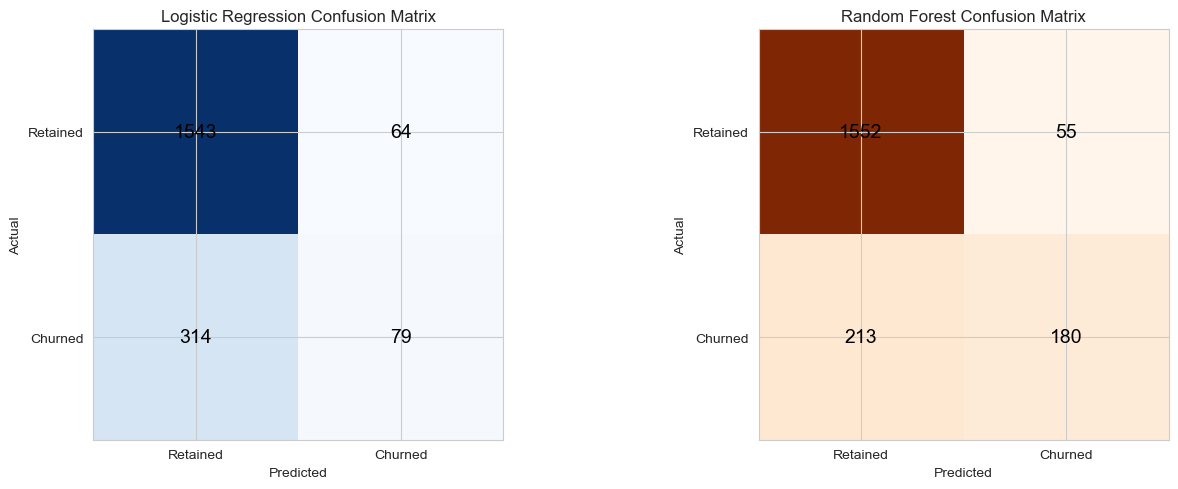

In [18]:
# Plot confusion matrices side by side to compare model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
axes[0].imshow(cm_lr, cmap="Blues")
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Retained", "Churned"])
axes[0].set_yticklabels(["Retained", "Churned"])

# Add numbers inside the confusion matrix cells
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_lr[i, j],
                    ha="center", va="center",
                    color="black", fontsize=14)

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
axes[1].imshow(cm_rf, cmap="Oranges")
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Retained", "Churned"])
axes[1].set_yticklabels(["Retained", "Churned"])

# Add numbers inside the confusion matrix cells
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_rf[i, j],
                    ha="center", va="center",
                    color="black", fontsize=14)

plt.tight_layout()
plt.show()

The confusion matrices reveal that both models perform well at predicting retained customers but struggle more with correctly identifying churned customers. The Random Forest model makes fewer false negatives meaning it misses fewer actual churned customers compared to Logistic Regression. This is particularly important in a business context where failing to identify a customer who will churn is more costly than incorrectly flagging a customer who will stay.

# Which model has better overall discrimination ability ?

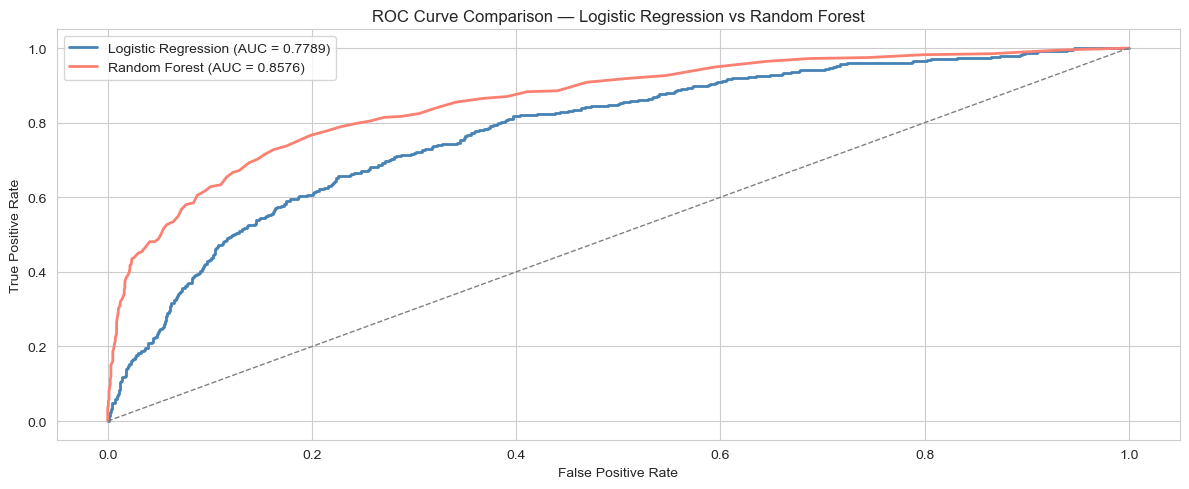

In [19]:
# Plot ROC curves for both models to compare performance visually
# ROC curve shows the tradeoff between true positive and false positive rates

# Get probability predictions for both models
lr_probs = lr_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Plot both curves
plt.plot(lr_fpr, lr_tpr, color="steelblue", linewidth=2,
         label=f"Logistic Regression (AUC = {lr_auc:.4f})")
plt.plot(rf_fpr, rf_tpr, color="salmon", linewidth=2,
         label=f"Random Forest (AUC = {rf_auc:.4f})")

# Add diagonal reference line — a random model would follow this line
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)

plt.title("ROC Curve Comparison — Logistic Regression vs Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

The ROC curve comparison clearly shows that Random Forest outperforms Logistic Regression across all classification thresholds with a higher AUC of 0.8576 compared to 0.7789. The Random Forest curve stays consistently above the Logistic Regression curve and further from the diagonal reference line which represents a random model. This confirms that Random Forest is the superior model for predicting bank customer churn.

# Which factors most influence whether a customer churns ?

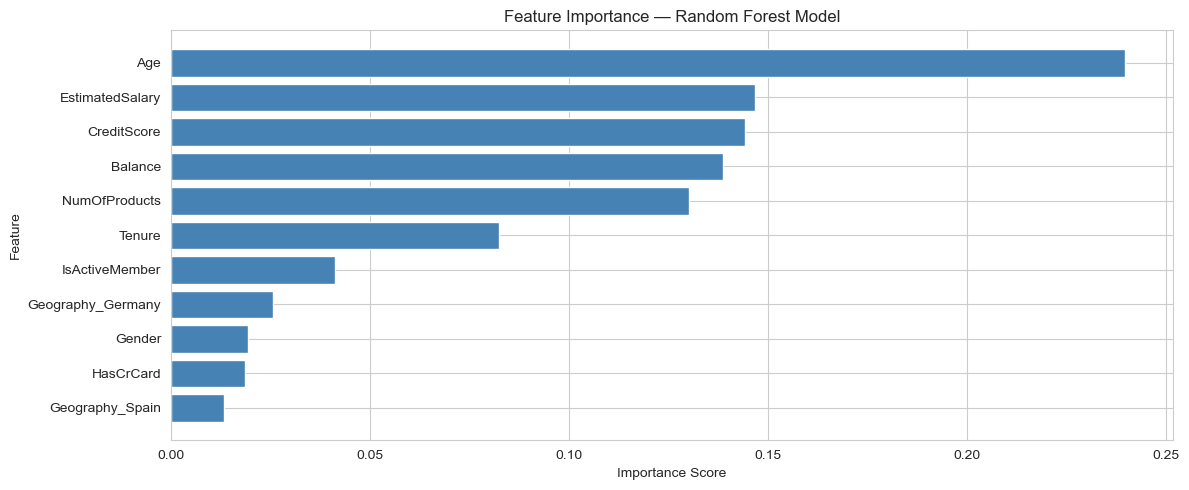

              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268


In [20]:
# Get feature importance from the Random Forest model
# Feature importance tells us which features most influence churn prediction
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

# Create a dataframe for easy plotting
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Plot feature importance
plt.barh(importance_df["Feature"], importance_df["Importance"],
         color="steelblue")
plt.title("Feature Importance — Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # Show most important feature at the top
plt.tight_layout()
plt.show()

print(importance_df)

In [21]:
# Final summary comparing both models
print("=== MODEL COMPARISON SUMMARY ===")
print(f"Total Customers in Test Set: {len(y_test)}")
print(f"\nLogistic Regression:")
print(f"  ROC AUC Score: {lr_auc:.4f}")
print(f"  Accuracy: {(lr_pred == y_test).mean():.4f}")
print(f"\nRandom Forest:")
print(f"  ROC AUC Score: {rf_auc:.4f}")
print(f"  Accuracy: {(rf_pred == y_test).mean():.4f}")
print(f"\nBest Model: {'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'}")
print(f"Most Important Churn Factor: {importance_df.iloc[0]['Feature']}")

=== MODEL COMPARISON SUMMARY ===
Total Customers in Test Set: 2000

Logistic Regression:
  ROC AUC Score: 0.7789
  Accuracy: 0.8110

Random Forest:
  ROC AUC Score: 0.8576
  Accuracy: 0.8660

Best Model: Random Forest
Most Important Churn Factor: Age
